In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

Create a CNN to classify the images

In [16]:
transformer = transforms.Compose([ # data size is 28x28 pixels, grayscale (1 channel)
        transforms.ToTensor(), # convert PIL image to PyTorch tensor and scale pixel values to [0, 1]])
        transforms.RandomHorizontalFlip(p=0.5), # randomly flip images horizontally with a probability of 0.5 ->
        # -> data augmentation technique to increase the diversity of the training data and help prevent overfitting
        transforms.Normalize(mean=[0.5], std=[0.5]) # normalize pixel values to [-1, 1]
])
data_train = datasets.FashionMNIST(root='data', train=True, download=True, transform=transformer) 
data_test = datasets.FashionMNIST(root='data', train=False, download=True, transform=transformer)    

# ToTensor(): This transform is lazy. It doesn't overwrite the original data in memory. 
# Instead, it only applies the conversion and scaling (-1 to 1) when the data is actually loaded (usually via a DataLoader or by indexing the dataset).
data_train.data.max()

tensor(255, dtype=torch.uint8)

In [17]:
print(data_train.classes) # check the class names, there are 10 classes in total
data_train.data.shape # check the shape of the data, there are 60000 images of 28x28 pixels

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


torch.Size([60000, 28, 28])

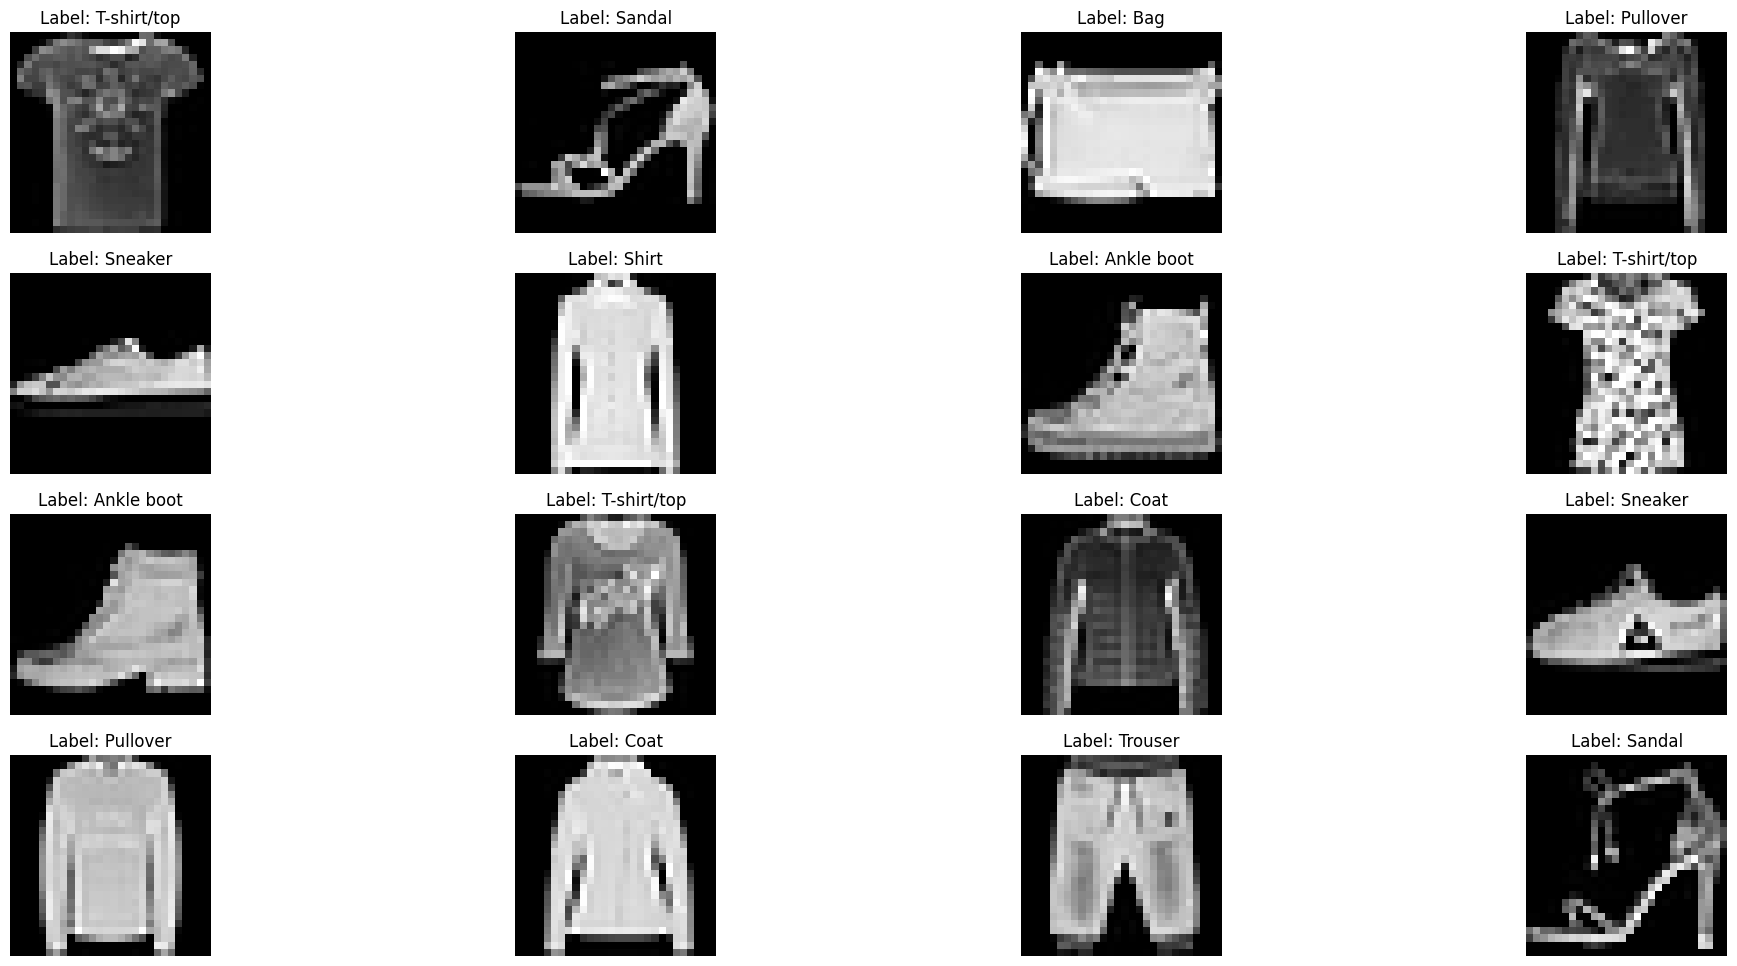

In [18]:
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(25, 12))

for ax in ax.flatten():
    random_index = torch.randint(0, len(data_train), size=[1]).item() # get a random index
    img = data_train.data[random_index] # get the image at the random index
    label = data_train.targets[random_index] # get the label at the random index
    ax.imshow(img, cmap="gray") # plot the image (squeeze to remove the channel dimension)
    ax.set_title(f"Label: {data_train.classes[label]}") # set the title to the class name
    ax.axis("off") # turn off the axis

In [19]:
data_val, data_test = train_test_split(data_test, test_size=0.5, random_state=42) # split the original test set into validation and test sets (50% each)

batch_size = 32
train_dataloader = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
val_dataloader = DataLoader(data_val, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(data_test, batch_size=batch_size, shuffle=False)

# check out a sample
images, labels = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
images.min(), images.max() # check the range of pixel values (should be between -1 and 1 due to normalization)

Image batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])


(tensor(-1.), tensor(1.))

In [ ]:
class FashionMNIST_CNN(nn.Module):
    def __init__(self, num_channels=(4, 8, 16)):
        super().__init__()
        # With k=3, padding=1, stride = 1, we came with size_in = size_out
        self.encoder = nn.Sequential(
            # input size = (1, 28, 28) for FashionMNIST
            nn.Conv2d(in_channels=1, out_channels=num_channels[0], kernel_size=3, stride=1, padding=1), # output size = np.floor((28 - 3 + 2*1) / 1) + 1 = 28
            nn.BatchNorm2d(num_features=num_channels[0]),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size = np.floor((28 - 2) / 2) + 1 = 14

            nn.Conv2d(in_channels=num_channels[0], out_channels=num_channels[1], kernel_size=3, stride=1, padding=1), # output size = np.floor((14 - 3 + 2*1) / 1) + 1 = 14
            nn.BatchNorm2d(num_features=num_channels[1]), 
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size  = np.floor((14 - 2) / 2) + 1 = 7

            nn.Conv2d(in_channels=num_channels[1], out_channels=num_channels[2], kernel_size=3, stride=1, padding=1), # output size = np.floor((7 - 3 + 2*1) / 1) + 1 = 7
            nn.BatchNorm2d(num_features=num_channels[2]), 
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size  = np.floor((7 - 2) / 2) + 1 = 3
        )

        self.fnn = nn.Sequential(
            nn.Flatten(), # flatten the output of the convolutional layers to feed into the fully connected layers
            nn.Linear(in_features=num_channels[2]*3*3, out_features=256),
            nn.LeakyReLU(),
            nn.Dropout(0.5), # add dropout to prevent overfitting
            nn.Linear(in_features=256, out_features=64),
            nn.LeakyReLU(),
            nn.Dropout(0.5), # add dropout to prevent overfitting
            nn.Linear(in_features=64, out_features=10) # 10 classes for FashionMNIST
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.fnn(x)
        
        return x
    
model = FashionMNIST_CNN(num_channels=(16, 32, 64))
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
       BatchNorm2d-2           [-1, 16, 28, 28]              32
         LeakyReLU-3           [-1, 16, 28, 28]               0
         MaxPool2d-4           [-1, 16, 14, 14]               0
            Conv2d-5           [-1, 32, 14, 14]           4,640
       BatchNorm2d-6           [-1, 32, 14, 14]              64
         LeakyReLU-7           [-1, 32, 14, 14]               0
         MaxPool2d-8             [-1, 32, 7, 7]               0
            Conv2d-9             [-1, 64, 7, 7]          18,496
      BatchNorm2d-10             [-1, 64, 7, 7]             128
        LeakyReLU-11             [-1, 64, 7, 7]               0
        MaxPool2d-12             [-1, 64, 3, 3]               0
          Flatten-13                  [-1, 576]               0
           Linear-14                  [

In [21]:
# test one forward pass to see the print statements in action
model = FashionMNIST_CNN(num_channels=(16, 32, 64))
loss_fn = nn.CrossEntropyLoss() # it implements both softmax and the negative log-likelihood loss
images, labels = next(iter(train_dataloader))
output = model(images)
predicted_classes = output.argmax(dim=1)
loss = loss_fn(output, labels)
print(f"Input shape: {images.shape}")
print(f"Output shape: {output.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Loss: {loss.item()}")

Input shape: torch.Size([32, 1, 28, 28])
Output shape: torch.Size([32, 10])
Labels shape: torch.Size([32])
Loss: 2.321120500564575


In [23]:
def train_one_epoch(model: torch.nn.Module,
                    train_dataloader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer,
                    ):
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0

    for batch, (X, y) in enumerate(train_dataloader):
        # Forward pass
        outputs = model(X)
        loss = loss_fn(outputs, y)

        # Update training loss and accuracy
        train_loss += loss.item()
        train_accuracy += (outputs.argmax(dim=1) == y).sum().item() # count the number of correct predictions

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss, train_accuracy


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          ):

    train_losses_epochs = []
    val_losses_epochs = []
    train_accuracy_epochs = []
    val_accuracy_epochs = []

    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_dataloader, loss_fn, optimizer)

        # Calculate average training loss and accuracy for the epoch
        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_accuracy = train_accuracy / len(train_dataloader.dataset)
        train_losses_epochs.append(avg_train_loss)
        train_accuracy_epochs.append(avg_train_accuracy)

        # Evaluate on the validation set
        model.eval()
        val_loss = 0.0
        val_accuracy = 0.0

        with torch.no_grad():
            for X, y in val_dataloader:
                outputs = model(X)
                loss = loss_fn(outputs, y)

                val_loss += loss.item()
                val_accuracy += (outputs.argmax(dim=1) == y).sum().item()

        avg_val_loss = val_loss / len(val_dataloader)
        avg_val_accuracy = val_accuracy / len(val_dataloader.dataset)
        val_losses_epochs.append(avg_val_loss)
        val_accuracy_epochs.append(avg_val_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Val Loss: {avg_val_loss:.4f}, "
            f"Train Accuracy: {avg_train_accuracy:.4f}, "
            f"Val Accuracy: {avg_val_accuracy:.4f}"
        )

    return train_losses_epochs, val_losses_epochs, train_accuracy_epochs, val_accuracy_epochs

In [24]:
loss_fn = nn.CrossEntropyLoss()
epochs = 10

model = FashionMNIST_CNN(num_channels=(16, 32, 64))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
train_loss, val_loss, train_accuracy, val_accuracy = train(model, train_dataloader, val_dataloader, loss_fn, optimizer, epochs)

Epoch [1/10], Train Loss: 0.6112, Val Loss: 0.4042, Train Accuracy: 0.7820, Val Accuracy: 0.8548
Epoch [2/10], Train Loss: 0.3884, Val Loss: 0.3454, Train Accuracy: 0.8672, Val Accuracy: 0.8744
Epoch [3/10], Train Loss: 0.3371, Val Loss: 0.3092, Train Accuracy: 0.8853, Val Accuracy: 0.8788
Epoch [4/10], Train Loss: 0.3062, Val Loss: 0.2839, Train Accuracy: 0.8944, Val Accuracy: 0.9028
Epoch [5/10], Train Loss: 0.2849, Val Loss: 0.2812, Train Accuracy: 0.9032, Val Accuracy: 0.9006
Epoch [6/10], Train Loss: 0.2720, Val Loss: 0.2731, Train Accuracy: 0.9070, Val Accuracy: 0.9032
Epoch [7/10], Train Loss: 0.2623, Val Loss: 0.2824, Train Accuracy: 0.9095, Val Accuracy: 0.9064
Epoch [8/10], Train Loss: 0.2492, Val Loss: 0.2523, Train Accuracy: 0.9144, Val Accuracy: 0.9120
Epoch [9/10], Train Loss: 0.2395, Val Loss: 0.2554, Train Accuracy: 0.9169, Val Accuracy: 0.9148
Epoch [10/10], Train Loss: 0.2335, Val Loss: 0.2642, Train Accuracy: 0.9198, Val Accuracy: 0.9100


In [25]:
# get the final test accuracy
model.eval()
test_loss = 0.0
test_accuracy = 0.0
with torch.no_grad():
    for X, y in test_dataloader:
        outputs = model(X)
        loss = loss_fn(outputs, y)

        test_loss += loss.item()
        test_accuracy += (outputs.argmax(dim=1) == y).sum().item()

# calculate the average test loss and accuracy
test_loss /= len(test_dataloader)
test_accuracy /= len(test_dataloader.dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2600
Test Accuracy: 0.9052


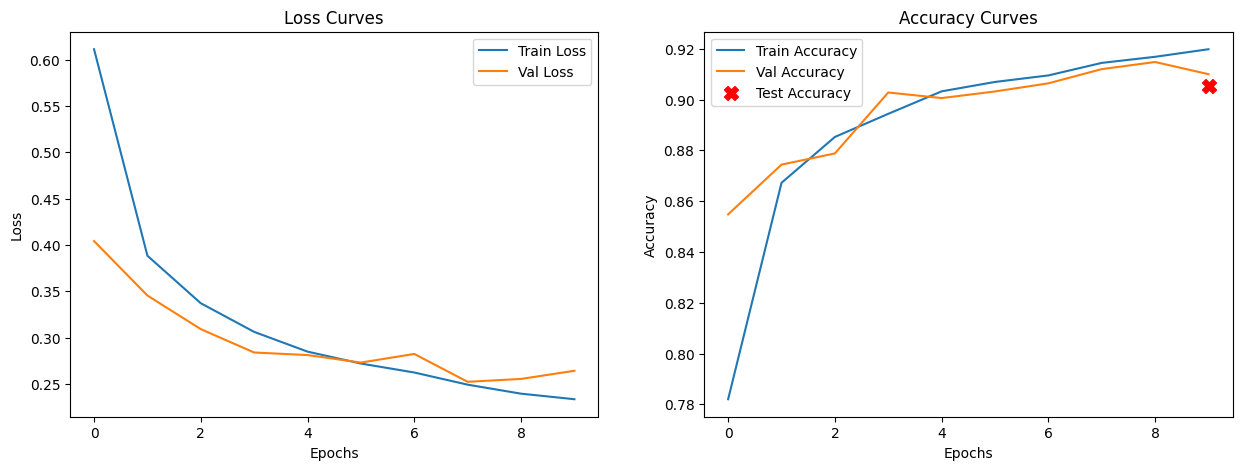

In [26]:
# plot loss and accuracy curves
plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label="Train Accuracy")
plt.plot(val_accuracy, label="Val Accuracy")
plt.scatter(epochs-1, test_accuracy, label="Test Accuracy", color="red", marker="X", s=100)
plt.title("Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# there is a small overfitting, so this means, we could have stopped training earlier, but we trained for 15 epochs to see the curves more clearly. 
# We could also add more regularization (e.g. dropout, weight decay) to reduce overfitting.